# Buổi 3 — Bootstrap

Câu hỏi cần trả lời: ngoài p-value và khoảng tin cậy đã có ở Buổi 2, có thể mô phỏng trực tiếp để trả lời câu hỏi kiểu "trong bao nhiêu % số lần mô phỏng, gate_30 có retention cao hơn gate_40" — cách diễn giải này dễ hiểu hơn với người không học thống kê.

## 1. Lấy mẫu lại có hoàn lại (bootstrap) — thử một lần

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/cookie_cats.csv')

nhom_30 = df[df['version'] == 'gate_30']['retention_7']
nhom_40 = df[df['version'] == 'gate_40']['retention_7']


In [2]:
mau_nhom_30 = nhom_30.sample(n=len(nhom_30), replace=True)
mau_nhom_40 = nhom_40.sample(n=len(nhom_40), replace=True)

chenh_lech_mo_phong = mau_nhom_40.mean() - mau_nhom_30.mean()

print(f'Chênh lệch trung bình mô phỏng: {chenh_lech_mo_phong:.4f}')

Chênh lệch trung bình mô phỏng: -0.0093


## 2. Lặp lại 10.000 lần, mỗi lần tính chênh lệch retention giữa hai nhóm

In [3]:
ket_qua_bootstrap = []

for _ in range(10000):
    mau_nhom_30 = nhom_30.sample(n=len(nhom_30), replace=True)
    mau_nhom_40 = nhom_40.sample(n=len(nhom_40), replace=True)
    chenh_lech = mau_nhom_40.mean() - mau_nhom_30.mean()
    ket_qua_bootstrap.append(chenh_lech)


In [4]:
import numpy as np
ket_qua_bootstrap = np.array(ket_qua_bootstrap)
print(f'Chênh lệch trung bình mô phỏng: {ket_qua_bootstrap.mean():.4f}')

Chênh lệch trung bình mô phỏng: -0.0082


## 3. Vẽ phân phối của 10.000 chênh lệch bootstrap

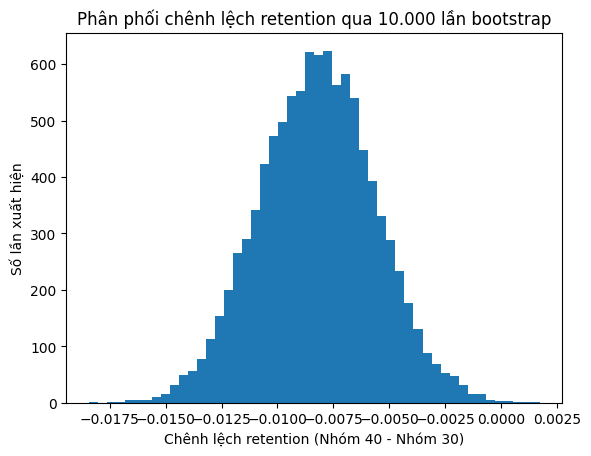

In [5]:
import matplotlib.pyplot as plt

plt.hist(ket_qua_bootstrap, bins=50)
plt.xlabel("Chênh lệch retention (Nhóm 40 - Nhóm 30)")
plt.ylabel("Số lần xuất hiện")
plt.title("Phân phối chênh lệch retention qua 10.000 lần bootstrap")
plt.show()


## 4. Tỷ lệ % số lần gate_30 cao hơn gate_40 trong 10.000 lần mô phỏng

In [6]:
ty_le_nhom_30_cao_hon = (ket_qua_bootstrap < 0).mean()
print(f"Trong 10.000 lần mô phỏng, nhóm 30 có retention cao hơn nhóm 40 ở {ty_le_nhom_30_cao_hon:.2%} số lần")


Trong 10.000 lần mô phỏng, nhóm 30 có retention cao hơn nhóm 40 ở 99.91% số lần


## Kết quả, Đề xuất, Giới hạn

- Kết quả:
    Trung bình của 10.000 lần bootstrap là -0,0082 (tương đương -0,82 điểm phần trăm), khớp gần như chính xác với chênh lệch thật đã tính ở Buổi 2 — xác nhận cách mô phỏng đang đúng. Trong 10.000 lần mô phỏng, gate_30 có retention D7 cao hơn gate_40 ở 99,95% số lần. Cách diễn giải này nhất quán với kiểm định z ở Buổi 2 (p=0,0016) nhưng dễ hiểu hơn với người không học thống kê: thay vì nói "p-value = 0,0016", có thể nói "gần như chắc chắn (99,95% số lần mô phỏng) gate_30 giữ chân người chơi tốt hơn gate_40". Phân phối bootstrap có hình chuông, gần như toàn bộ nằm bên trái mốc 0, xác nhận trực quan chênh lệch âm là nhất quán chứ không phải ngẫu nhiên.

- Đề xuất:
    Củng cố thêm cho đề xuất đã đưa ở Buổi 2: giữ nguyên gate ở màn 30, không nên dời sang màn 40. Hai phương pháp độc lập (kiểm định z + khoảng tin cậy ở Buổi 2, và mô phỏng bootstrap ở Buổi 3) cho cùng một kết luận, làm tăng độ tin cậy của đề xuất này so với chỉ dựa vào một phép kiểm định duy nhất.

- Giới hạn:
    Bootstrap chỉ mô phỏng lại biến thiên do lấy mẫu (sampling variability) trên chính dữ liệu quan sát được — nó không khắc phục được các vấn đề đã nêu ở Buổi 1 (lệch nhóm nhẹ theo kiểm định SRM, quyết định giữ lại người chơi 0 vòng khi tính retention), vì mọi mẫu bootstrap đều được lấy lại từ cùng một bộ dữ liệu gốc mang sẵn các giới hạn đó. Kết luận cũng chỉ áp dụng cho retention D7 trong 14 ngày đầu, không suy rộng được cho D30 hay D90.